# Tech Challenge — Fase 1: Saúde e Segurança da Mulher

## Objetivo

Aplicar fundamentos de **Inteligência Artificial e Machine Learning** para processamento de dados médicos relacionados à **saúde feminina**, com foco em acompanhamento gestacional.

**Dataset**: SIASI — Acompanhamento Gestacional (GovBr)  
Fonte: https://dados.gov.br/dados/conjuntos-dados/acompanhamento-gestacional-siasi

O objetivo é construir um pipeline completo de ML que classifique o **risco gestacional**, permitindo que profissionais de saúde tenham suporte baseado em dados para a tomada de decisão clínica.

> ⚠️ **Aviso ético**: este modelo é um **suporte à decisão** e não substitui avaliação médica profissional. O médico sempre deve ter a palavra final no diagnóstico.

---

**Escopo deste notebook**: estudo principal do projeto — EDA dos dados brutos, engenharia de features, análise pós-tratamento (incluindo a **comparação pré/pós-pandemia 2019 × 2024**, seção 6.1), modelagem com estudo de ablação, avaliação e explicabilidade. O estudo comparativo com o dataset clínico **Maternal Health Risk** está no notebook `02_maternal_risk.ipynb`.

In [1]:
# Instalação de dependências (caso necessário)
# !pip install -r ../requirements.txt

In [2]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Adiciona src/ ao path para importar módulos locais
sys.path.insert(0, str(Path("..").resolve() / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


## 1. Configuração

Constantes já configuradas para o dataset real (`prenatal_microdados_2024.csv`). As colunas originais do SIASI têm nomes crípticos (`co_`, `ds_`, `dt_`, `st_`...) e são renomeadas para nomes autoexplicativos logo após o carregamento — as constantes abaixo já usam os nomes renomeados.

Pontos importantes descobertos na análise do dataset:
- **Cada linha é uma consulta de pré-natal**, não uma gestante — a mesma gestação (`id_gestacao`) aparece em ~6,4 linhas em média.
- `data_finalizacao` e `motivo_finalizacao` só são conhecidas **ao fim da gestação** e, por isso, não podem ser usadas como features (data leakage).

In [3]:
# ─── Configuração principal ────────────────────────────────────────────────
# Nomes já no padrão renomeado (ver célula de renomeação na seção 2)
TARGET_COL = "risco_gestacional"             # A = alto risco | B = baixo risco
DATA_FILE  = "prenatal_microdados_2024.csv"  # Dataset principal (pós-pandemia)
DATA_FILE_2019 = "prenatal_microdados_2019.csv"  # Para comparação pré-pandemia (seção 6.1)
GROUP_COL  = "id_gestacao"                   # Identificador da gestação (para o split)
LEAKAGE_COLS = ["data_finalizacao", "motivo_finalizacao"]  # Só conhecidas ao fim da gestação
RANDOM_STATE = 42
TEST_SIZE    = 0.2
RAW_DIR      = Path("..") / "data" / "siasi" / "raw"
PROCESSED_DIR = Path("..") / "data" / "siasi" / "processed"
FIGURES_DIR  = Path("..") / "reports" / "figures"
METRICS_DIR  = Path("..") / "reports" / "metrics"
# ────────────────────────────────────────────────────────────────────────────
print(f"Alvo    : {TARGET_COL}")
print(f"Arquivo : {DATA_FILE}")
print(f"Grupo   : {GROUP_COL}")

Alvo    : risco_gestacional
Arquivo : prenatal_microdados_2024.csv
Grupo   : id_gestacao


## 2. Carregamento dos Dados

In [4]:
from data_loader import load_csv, basic_validation, detect_target_column

df = load_csv(DATA_FILE)
df.head()

Dataset carregado: 127281 linhas × 26 colunas


,dsei_gestao,co_dsei_gestao,cod_polo_base,ds_polo_base,co_terra_indigena,no_terra_indigena,co_municipio_ibge,no_municipio,sg_uf,co_indio_desidentificado,dt_nascimento,tp_sexo,co_localidade,co_gestacao_desidentificado,dt_ultima_menstruacao,dt_finalizacao,co_seq_acompanhamento_gestacao,dt_acompanhamento,st_risco_gestacional,tp_local_atendimento,co_profissional,co_cbo_familia,ds_cbo_familia,co_ocupacao,ds_cbo_ocupacao,st_motivo_finalizacao
0,ALAGOAS E SERGIPE,1,1601,ACONÃ,3,ACONÃ,270920,TRAIPU,AL,3CAD29F3F19692820FECD0EE31C2D9CCE7227BC5,2008/03/23 00:00:00.000,F,ALD,A82F0D54F89273DBC2C7D3A57D2102701044E7A1,2023/04/27 00:00:00.000,2024/02/29 00:00:00.000,06f029bdb0e044259934b697b4c87a04,2024/01/23 00:00:00.000,B,PL,62016.0000,2235.0000,ENFERMEIROS E AFINS,223505.0000,Enfermeiro,NAS
1,ALAGOAS E SERGIPE,1,1601,ACONÃ,3,ACONÃ,270920,TRAIPU,AL,3CAD29F3F19692820FECD0EE31C2D9CCE7227BC5,2008/03/23 00:00:00.000,F,ALD,A82F0D54F89273DBC2C7D3A57D2102701044E7A1,2023/04/27 00:00:00.000,2024/02/29 00:00:00.000,a399a8be9d14462594bfa7107a9f669a,2024/01/18 00:00:00.000,NaN,PL,46056.0000,2232.0000,CIRURGIÕES-DENTISTAS,223208.0000,Cirurgião dentista - clínico geral,NAS
2,ALAGOAS E SERGIPE,1,1601,ACONÃ,3,ACONÃ,270920,TRAIPU,AL,3CAD29F3F19692820FECD0EE31C2D9CCE7227BC5,2008/03/23 00:00:00.000,F,ALD,A82F0D54F89273DBC2C7D3A57D2102701044E7A1,2023/04/27 00:00:00.000,2024/02/29 00:00:00.000,0e05583db6994842b3b144dee610fa6f,2024/01/16 00:00:00.000,B,PL,62016.0000,2235.0000,ENFERMEIROS E AFINS,223505.0000,Enfermeiro,NAS
3,ALAGOAS E SERGIPE,1,1601,ACONÃ,3,ACONÃ,270920,TRAIPU,AL,3CAD29F3F19692820FECD0EE31C2D9CCE7227BC5,2008/03/23 00:00:00.000,F,ALD,A82F0D54F89273DBC2C7D3A57D2102701044E7A1,2023/04/27 00:00:00.000,2024/02/29 00:00:00.000,fb419e22366b4e65938f006fb2500947,2023/12/18 00:00:00.000,NaN,PL,46056.0000,2232.0000,CIRURGIÕES-DENTISTAS,223208.0000,Cirurgião dentista - clínico geral,NAS
4,ALAGOAS E SERGIPE,1,1601,ACONÃ,3,ACONÃ,270920,TRAIPU,AL,3CAD29F3F19692820FECD0EE31C2D9CCE7227BC5,2008/03/23 00:00:00.000,F,ALD,A82F0D54F89273DBC2C7D3A57D2102701044E7A1,2023/04/27 00:00:00.000,2024/02/29 00:00:00.000,a8ada31d53a24d97a467ef7f6b07aced,2023/12/12 00:00:00.000,B,PL,62016.0000,2235.0000,ENFERMEIROS E AFINS,223505.0000,Enfermeiro,NAS


In [5]:
# Renomeia as colunas para nomes autoexplicativos. Os originais seguem o padrão
# SIASI: co_ = código | ds_/no_ = descrição/nome | dt_ = data | st_ = status | tp_ = tipo
RENAME_MAP = {
    "dsei_gestao": "nome_dsei",                       # Distrito Sanitário Especial Indígena
    "co_dsei_gestao": "codigo_dsei",
    "cod_polo_base": "codigo_polo_base",
    "ds_polo_base": "nome_polo_base",
    "co_terra_indigena": "codigo_terra_indigena",
    "no_terra_indigena": "nome_terra_indigena",
    "co_municipio_ibge": "codigo_municipio_ibge",
    "no_municipio": "nome_municipio",
    "sg_uf": "uf",
    "co_indio_desidentificado": "id_gestante",        # hash anonimizado da paciente
    "dt_nascimento": "data_nascimento",
    "tp_sexo": "sexo",
    "co_localidade": "tipo_localidade",
    "co_gestacao_desidentificado": "id_gestacao",     # hash anonimizado da gestação
    "dt_ultima_menstruacao": "data_ultima_menstruacao",
    "dt_finalizacao": "data_finalizacao",
    "co_seq_acompanhamento_gestacao": "id_consulta",
    "dt_acompanhamento": "data_consulta",
    "st_risco_gestacional": "risco_gestacional",
    "tp_local_atendimento": "local_atendimento",
    "co_profissional": "codigo_profissional",
    "co_cbo_familia": "codigo_familia_ocupacao",
    "ds_cbo_familia": "categoria_profissional",
    "co_ocupacao": "codigo_ocupacao",
    "ds_cbo_ocupacao": "ocupacao_profissional",
    "st_motivo_finalizacao": "motivo_finalizacao",
}
df = df.rename(columns=RENAME_MAP)
print(f"{len(RENAME_MAP)} colunas renomeadas. Colunas atuais:")
print(sorted(df.columns.tolist()))

26 colunas renomeadas. Colunas atuais:
['categoria_profissional', 'codigo_dsei', 'codigo_familia_ocupacao', 'codigo_municipio_ibge', 'codigo_ocupacao', 'codigo_polo_base', 'codigo_profissional', 'codigo_terra_indigena', 'data_consulta', 'data_finalizacao', 'data_nascimento', 'data_ultima_menstruacao', 'id_consulta', 'id_gestacao', 'id_gestante', 'local_atendimento', 'motivo_finalizacao', 'nome_dsei', 'nome_municipio', 'nome_polo_base', 'nome_terra_indigena', 'ocupacao_profissional', 'risco_gestacional', 'sexo', 'tipo_localidade', 'uf']


In [6]:
report = basic_validation(df)


=== Validação básica ===
Shape       : (127281, 26)
Duplicados  : 0
Colunas com missing:
risco_gestacional         14.0600
codigo_profissional        6.2000
codigo_familia_ocupacao    6.2000
categoria_profissional     6.2000
codigo_ocupacao            6.2000
ocupacao_profissional      6.2000
dtype: float64


In [7]:
# Confirmação da coluna alvo e distribuição das classes (incluindo sem rótulo)
assert TARGET_COL in df.columns, f"Coluna alvo '{TARGET_COL}' não encontrada!"
print(f"Coluna alvo confirmada: '{TARGET_COL}'\n")
print(df[TARGET_COL].value_counts(dropna=False).rename({np.nan: "(sem rótulo)"}))

Coluna alvo confirmada: 'risco_gestacional'

risco_gestacional
B               92442
(sem rótulo)    17895
A               16944
Name: count, dtype: int64


## 3. Análise Exploratória de Dados (EDA) — Dados Brutos

Primeira leitura do dataset **como ele veio da fonte** (apenas com as colunas renomeadas): estatísticas descritivas, distribuição do alvo, valores ausentes e distribuições numéricas. A análise das variáveis tratadas/derivadas é repetida na seção 6, permitindo comparar o antes e o depois do tratamento.

In [8]:
print(f"Shape: {df.shape}")
print(f"\nTipos de dados:")
print(df.dtypes.value_counts())
print(f"\nEstatísticas descritivas:")
df.describe(include="all").T.head(30)

Shape: (127281, 26)

Tipos de dados:
str        19
int64       4
float64     3
Name: count, dtype: int64

Estatísticas descritivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
nome_dsei,127281,34,ALTO RIO SOLIMÕES,14352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
codigo_dsei,127281.0000,NaN,NaN,NaN,19.3326,9.9309,1.0000,10.0000,20.0000,28.0000,36.0000
codigo_polo_base,127281.0000,NaN,NaN,NaN,1713.8306,121.7711,1505.0000,1629.0000,1723.0000,1792.0000,2177.0000
nome_polo_base,127281,369,DOURADOS,4100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
codigo_terra_indigena,127281.0000,NaN,NaN,NaN,976.2928,2427.2939,2.0000,135.0000,361.0000,548.0000,10219.0000
nome_terra_indigena,127281,510,YANOMAMI,4616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
codigo_municipio_ibge,127281.0000,NaN,NaN,NaN,255963.2264,145610.5807,110001.0000,130380.0000,210060.0000,411820.0000,521890.0000
nome_municipio,127281,454,SAO GABRIEL DA CACHOEIRA,4216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uf,127281,25,AM,37152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_gestante,127281,19830,2156021EBBC93835BD776D1D664D10F75E32F5AE,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN


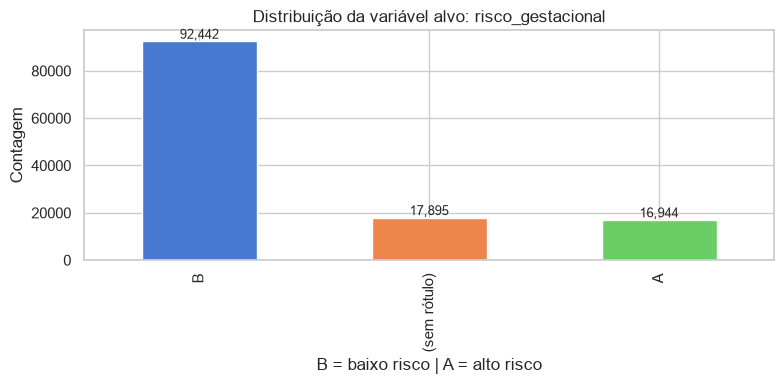


Proporção (%):
risco_gestacional
B              72.6300
(sem rótulo)   14.0600
A              13.3100


In [9]:
# Distribuição da variável alvo (incluindo registros sem rótulo)
fig, ax = plt.subplots(figsize=(8, 4))
vc = df[TARGET_COL].value_counts(dropna=False).rename({np.nan: "(sem rótulo)"})
vc.plot(kind="bar", ax=ax, color=sns.color_palette("muted"))
ax.set_title(f"Distribuição da variável alvo: {TARGET_COL}")
ax.set_xlabel("B = baixo risco | A = alto risco")
ax.set_ylabel("Contagem")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150)
plt.show()
print("\nProporção (%):")
print((vc / len(df) * 100).round(2).to_string())

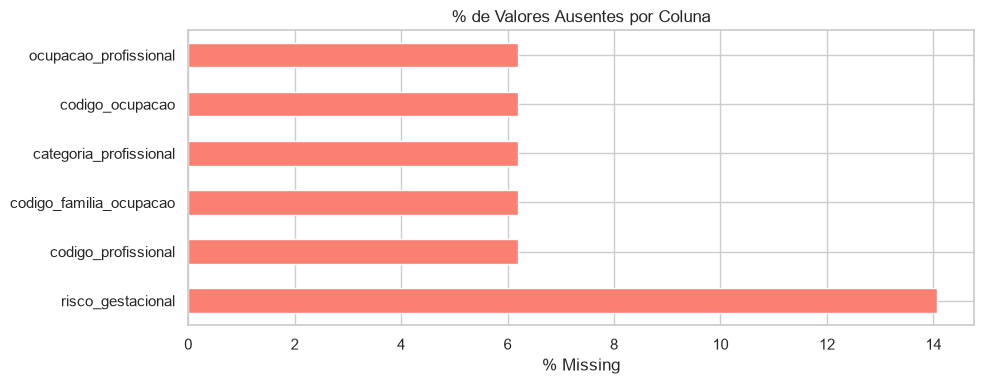

In [10]:
# Missingness
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_pct)*0.4)))
    missing_pct.plot(kind="barh", ax=ax, color="salmon")
    ax.set_title("% de Valores Ausentes por Coluna")
    ax.set_xlabel("% Missing")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "missing_values.png", dpi=150)
    plt.show()
else:
    print("Não há valores ausentes no dataset.")

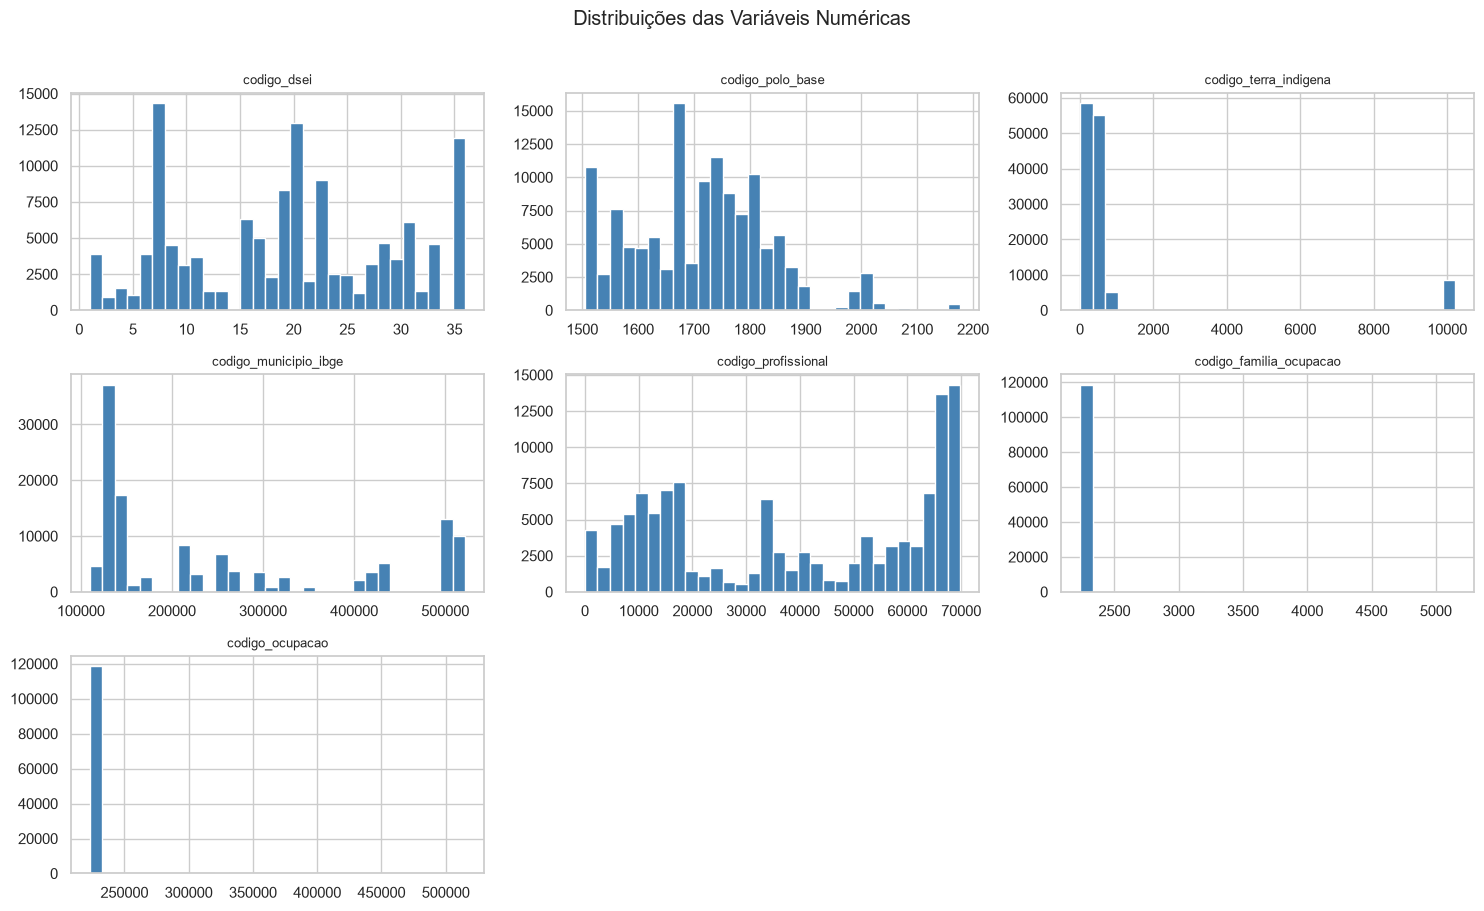

In [11]:
# Distribuições numéricas
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
if TARGET_COL in num_cols:
    num_cols.remove(TARGET_COL)

n_plots = min(len(num_cols), 12)
if n_plots > 0:
    ncols = 3
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
    axes = axes.flatten()
    for i, col in enumerate(num_cols[:n_plots]):
        df[col].hist(ax=axes[i], bins=30, edgecolor="white", color="steelblue")
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel("")
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Distribuições das Variáveis Numéricas", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "numeric_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4. Análise de Correlação — Dados Brutos

Correlação de Pearson entre as colunas numéricas **originais**. Duas limitações importantes desta visão:

1. As únicas colunas numéricas cruas são **códigos administrativos** (`codigo_dsei`, `codigo_municipio_ibge`...) — números arbitrários de cadastro, cuja correlação não tem significado prático;
2. O alvo (`risco_gestacional`, categórico A/B) não aparece na matriz.

É exatamente essa pobreza que motiva a engenharia de features da seção 5 — a matriz é refeita na seção 6, já com variáveis clínicas e o alvo codificado.

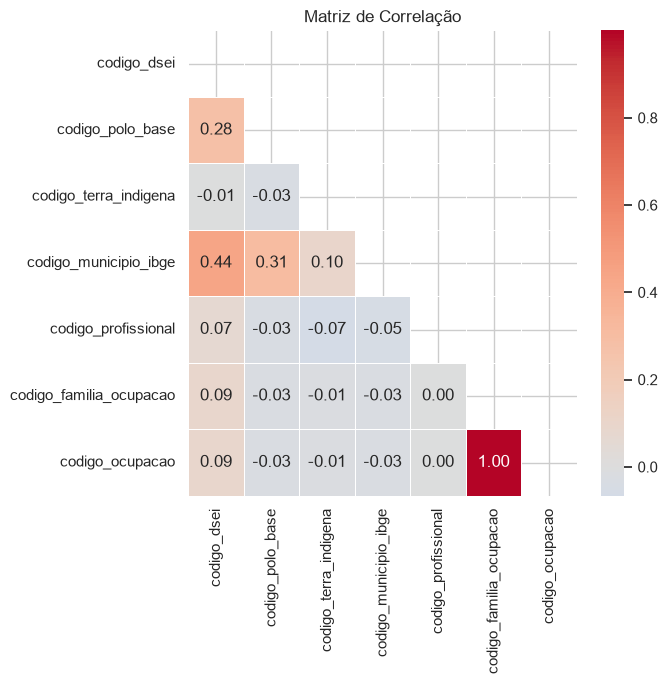

In [12]:
num_df = df[num_cols].copy()
if len(num_cols) > 1:
    corr = num_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(min(16, len(num_cols)), min(14, len(num_cols))))
    sns.heatmap(corr, mask=mask, annot=len(num_cols) <= 15, fmt=".2f",
                cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
    ax.set_title("Matriz de Correlação")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=150)
    plt.show()
else:
    print("Poucas colunas numéricas para análise de correlação.")

## 5. Engenharia de Features Derivadas

As colunas mais informativas do dataset são **datas armazenadas como texto** (`data_nascimento`, `data_ultima_menstruacao`, `data_consulta`), que o modelo não consegue usar diretamente — por alta cardinalidade, seriam descartadas no pré-processamento. Convertemos essas datas (e a categoria do profissional) em **variáveis com significado clínico**:

| Feature | Cálculo | Interpretação |
|---|---|---|
| `idade_gestante` | consulta − nascimento | Idade em anos na consulta |
| `idade_gestacional_semanas` | consulta − última menstruação | Semana da gestação na consulta |
| `num_consulta` | ordem da consulta na gestação | Intensidade do acompanhamento até ali |
| `semana_inicio_prenatal` | semana gestacional da 1ª consulta | Precocidade do pré-natal |
| `trimestre_inicio_prenatal` | faixa da semana de início | 1º, 2º ou 3º trimestre |
| `atendida_por_medico` | categoria profissional contém "MÉDICOS" | Consulta realizada por médico (0/1) |
| `atendida_por_enfermeiro` | categoria profissional contém "ENFERMEIROS" | Consulta realizada por enfermeiro (0/1) |

Decisões metodológicas:
- Valores impossíveis (idade fora de 8–60 anos; idade gestacional negativa ou >45 semanas) viram `NaN` e serão imputados pela mediana no pré-processamento.
- `num_consulta` usa **apenas consultas passadas** (contagem cumulativa) — o total de consultas da gestação só é conhecido no fim e seria vazamento de dados.
- Nos indicadores de profissional, técnicos/auxiliares de enfermagem **não** contam como enfermeiro, e as consultas sem profissional registrado (6,2%) recebem 0 em ambos.
- As novas features entram na análise pós-tratamento (seção 6), no pré-processamento e no treinamento.

In [13]:
DATE_FORMAT = "%Y/%m/%d %H:%M:%S.%f"

new_feats = ["idade_gestante", "idade_gestacional_semanas", "num_consulta",
             "semana_inicio_prenatal", "trimestre_inicio_prenatal",
             "atendida_por_medico", "atendida_por_enfermeiro"]


def adiciona_features_derivadas(d: pd.DataFrame) -> pd.DataFrame:
    """Deriva as features clínicas a partir das datas e da categoria profissional.
    Função reutilizável: aplicada ao dataset de 2024 aqui e ao de 2019 na seção 6.1."""
    d = d.copy()

    # Conversão das datas (texto → datetime)
    for col in ["data_nascimento", "data_ultima_menstruacao", "data_consulta"]:
        d[col + "_parsed"] = pd.to_datetime(d[col], format=DATE_FORMAT, errors="coerce")

    # Idade da gestante na data da consulta (anos); valores impossíveis viram NaN
    d["idade_gestante"] = (d["data_consulta_parsed"] - d["data_nascimento_parsed"]).dt.days / 365.25
    d.loc[(d["idade_gestante"] < 8) | (d["idade_gestante"] > 60), "idade_gestante"] = np.nan

    # Idade gestacional na consulta (semanas desde a última menstruação)
    d["idade_gestacional_semanas"] = (
        d["data_consulta_parsed"] - d["data_ultima_menstruacao_parsed"]
    ).dt.days / 7
    d.loc[
        (d["idade_gestacional_semanas"] < 0) | (d["idade_gestacional_semanas"] > 45),
        "idade_gestacional_semanas",
    ] = np.nan

    # Ordem da consulta dentro da gestação (1ª, 2ª, 3ª...). Usa apenas o passado:
    # o TOTAL de consultas da gestação só é conhecido no fim (seria leakage)
    d = d.sort_values([GROUP_COL, "data_consulta_parsed"])
    d["num_consulta"] = d.groupby(GROUP_COL).cumcount() + 1

    # Semana gestacional em que o pré-natal começou (1ª consulta da gestação)
    # e o trimestre correspondente (1º: <14 sem | 2º: 14–27 | 3º: 28+)
    d["semana_inicio_prenatal"] = d.groupby(GROUP_COL)["idade_gestacional_semanas"].transform("min")
    d["trimestre_inicio_prenatal"] = pd.cut(
        d["semana_inicio_prenatal"], bins=[0, 14, 28, 45], labels=[1, 2, 3]
    ).astype(float)

    # Indicadores do tipo de profissional (1 = sim, 0 = não). "MÉDICOS" cobre clínicos
    # e especialidades cirúrgicas; técnicos/auxiliares de enfermagem NÃO contam como
    # enfermeiro; consultas sem profissional registrado ficam 0
    d["atendida_por_medico"] = d["categoria_profissional"].str.contains("MÉDICOS", na=False).astype(int)
    d["atendida_por_enfermeiro"] = d["categoria_profissional"].str.contains("ENFERMEIROS", na=False).astype(int)

    return d.drop(columns=[c for c in d.columns if c.endswith("_parsed")])


df = adiciona_features_derivadas(df)
df[new_feats].describe().T

,count,mean,std,min,25%,50%,75%,max
idade_gestante,127281.0000,24.9007,6.9600,8.6872,19.3730,23.8275,29.5414,55.4415
idade_gestacional_semanas,127267.0000,24.1867,9.4249,0.0000,16.7143,24.8571,32.1429,44.2857
num_consulta,127281.0000,4.5347,2.9363,1.0000,2.0000,4.0000,6.0000,23.0000
semana_inicio_prenatal,127280.0000,12.1672,6.2281,0.0000,7.7143,10.7143,15.4286,41.1429
trimestre_inicio_prenatal,126550.0000,1.3299,0.5135,1.0000,1.0000,1.0000,2.0000,3.0000
atendida_por_medico,127281.0000,0.2465,0.4310,0.0000,0.0000,0.0000,0.0000,1.0000
atendida_por_enfermeiro,127281.0000,0.5572,0.4967,0.0000,0.0000,1.0000,1.0000,1.0000


## 6. Análise Pós-Tratamento

Repetimos a análise, agora com as features derivadas, para comparar com a visão dos dados brutos (seções 3–4):

1. Distribuição das novas variáveis por classe de risco;
2. Nova matriz de correlação incluindo as derivadas **e o alvo codificado** (`risco_alto`: A=1, B=0) — os códigos administrativos (`codigo_*`) ficam de fora, pois são números arbitrários;
3. Exportação do dataset tratado para `data/processed/`.

> **Nota metodológica**: correlação baixa com o alvo não justifica, sozinha, remover uma feature. A correlação de Pearson só captura relações **lineares** — uma relação em "U" (como idade × risco) aparece como ~0 e ainda assim é aprendida pela árvore. O critério final de utilidade de uma feature é a combinação de feature importance/SHAP (seção 10) com a ablação (seção 8.1). Já **alta** correlação entre duas features indica redundância — este sim é um critério de remoção que a matriz oferece.

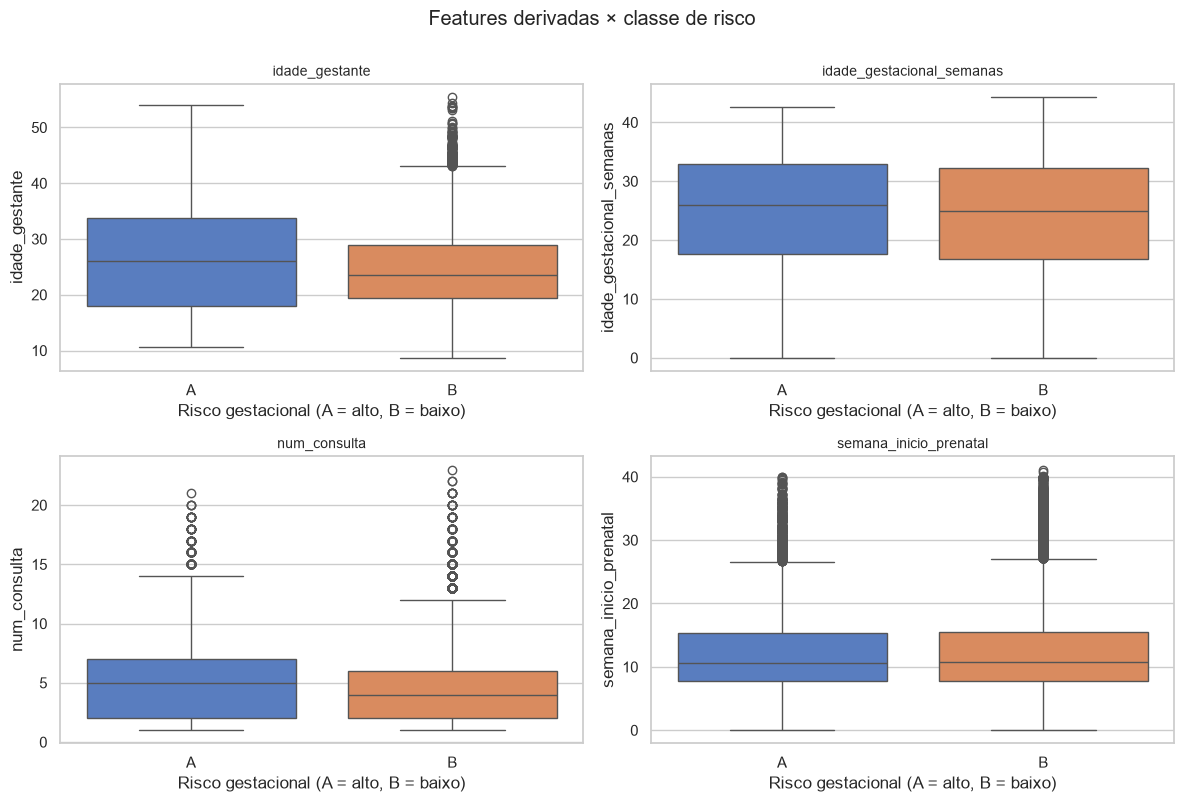

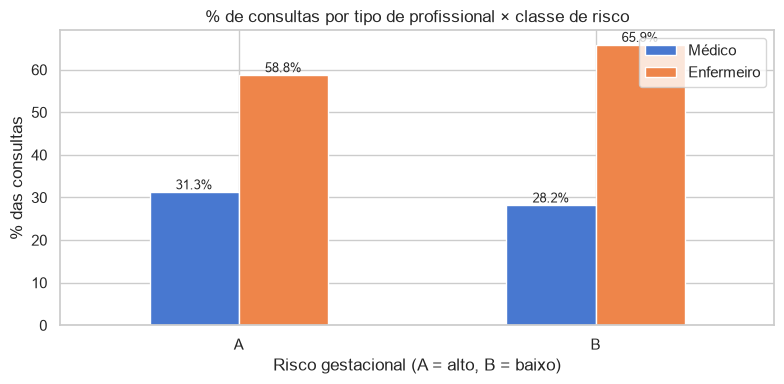

In [14]:
# Distribuição das features derivadas por classe de risco
plot_feats = ["idade_gestante", "idade_gestacional_semanas", "num_consulta", "semana_inicio_prenatal"]
labeled = df.dropna(subset=[TARGET_COL])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), plot_feats):
    sns.boxplot(data=labeled, x=TARGET_COL, y=col, ax=ax, order=["A", "B"], palette="muted")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Risco gestacional (A = alto, B = baixo)")
plt.suptitle("Features derivadas × classe de risco", y=1.0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "derived_features_by_risk.png", dpi=150, bbox_inches="tight")
plt.show()

# Indicadores de profissional: % de consultas por médico/enfermeiro em cada classe
taxas = labeled.groupby(TARGET_COL)[["atendida_por_medico", "atendida_por_enfermeiro"]].mean() * 100
ax = taxas.plot(kind="bar", figsize=(8, 4), rot=0, edgecolor="white", color=sns.color_palette("muted"))
ax.set_title("% de consultas por tipo de profissional × classe de risco")
ax.set_xlabel("Risco gestacional (A = alto, B = baixo)")
ax.set_ylabel("% das consultas")
ax.legend(["Médico", "Enfermeiro"], loc="upper right")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "professional_by_risk.png", dpi=150)
plt.show()

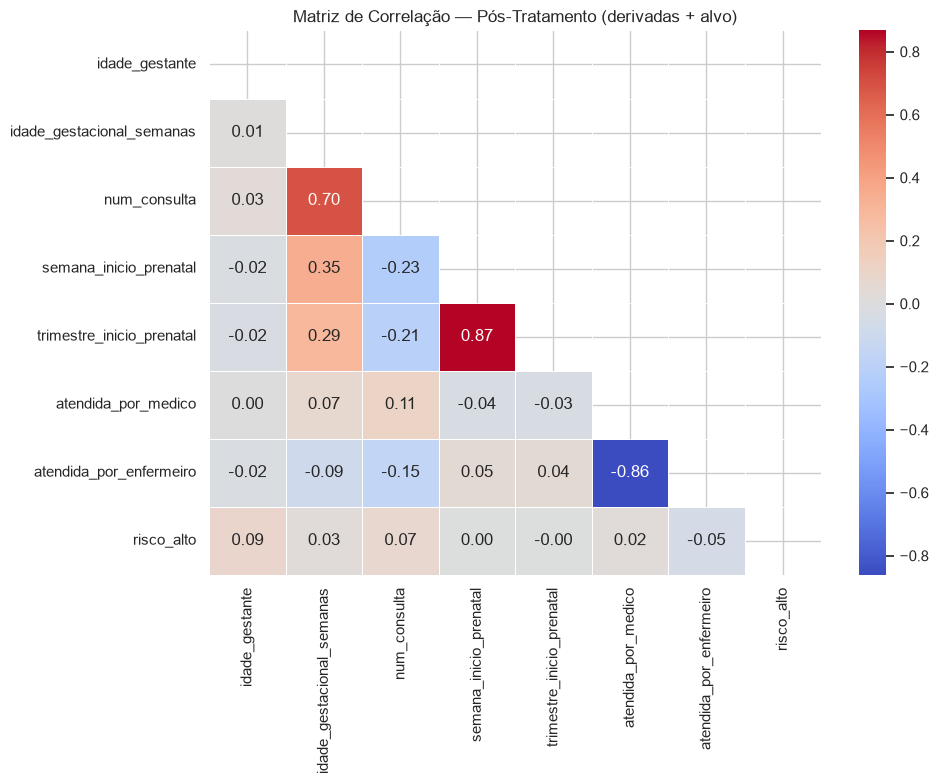

Correlação de cada feature com o alvo (risco_alto), da mais forte à mais fraca:
idade_gestante               0.0910
num_consulta                 0.0720
atendida_por_enfermeiro     -0.0540
idade_gestacional_semanas    0.0300
atendida_por_medico          0.0250
trimestre_inicio_prenatal   -0.0020
semana_inicio_prenatal       0.0010


In [15]:
# Correlação pós-tratamento: features derivadas + alvo codificado (A=1, B=0).
# Códigos administrativos (codigo_*) ficam de fora: são números arbitrários de cadastro
df_pos = df.dropna(subset=[TARGET_COL]).copy()
df_pos["risco_alto"] = (df_pos[TARGET_COL] == "A").astype(int)

cols_pos = [c for c in df_pos.select_dtypes(include=["number"]).columns
            if not c.startswith("codigo_")]
corr_pos = df_pos[cols_pos].corr()

mask = np.triu(np.ones_like(corr_pos, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_pos, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Matriz de Correlação — Pós-Tratamento (derivadas + alvo)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix_pos_tratamento.png", dpi=150)
plt.show()

print("Correlação de cada feature com o alvo (risco_alto), da mais forte à mais fraca:")
print(corr_pos["risco_alto"].drop("risco_alto").sort_values(key=abs, ascending=False).round(3).to_string())

In [16]:
# Exporta o dataset tratado (colunas renomeadas + features derivadas) para reuso
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_csv = PROCESSED_DIR / "prenatal_tratado_2024.csv"
df.to_csv(out_csv, sep=";", index=False, encoding="utf-8")
print(f"CSV tratado salvo em: {out_csv.resolve()}")
print(f"{df.shape[0]} linhas × {df.shape[1]} colunas")

CSV tratado salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\data\siasi\processed\prenatal_tratado_2024.csv
127281 linhas × 33 colunas


### 6.1 Comparação 2019 × 2024 — pré e pós-pandemia

O SIASI disponibiliza os microdados de vários anos com o **mesmo esquema de colunas**. Comparamos 2019 (último ano completo antes da COVID-19) com 2024 para investigar se o perfil do pré-natal indígena mudou entre o período **pré-pandemia** e o **pós-pandemia**: proporção de alto risco, cobertura de rótulo, idade das gestantes, precocidade e intensidade do acompanhamento, tipo de profissional e desfechos (aborto/óbito fetal).

> **Cuidado na interpretação**: diferenças entre os anos podem refletir tanto mudanças **reais** no perfil das gestantes e da assistência quanto mudanças de **prática de registro** no sistema (ex.: mais consultas digitadas, critérios de classificação de risco atualizados). O correto é ler os números como "o que o sistema registrou", não diretamente como "o que aconteceu na população".

In [17]:
# Carrega 2019 e aplica o MESMO tratamento do 2024 (renomeação + features derivadas)
df19 = load_csv(DATA_FILE_2019).rename(columns=RENAME_MAP)
df19 = adiciona_features_derivadas(df19)

# Exporta também o dataset tratado de 2019 (mesmo formato do de 2024)
out_csv_19 = PROCESSED_DIR / "prenatal_tratado_2019.csv"
df19.to_csv(out_csv_19, sep=";", index=False, encoding="utf-8")
print(f"CSV tratado salvo em: {out_csv_19.resolve()} ({df19.shape[0]} linhas x {df19.shape[1]} colunas)")


def resumo_ano(d: pd.DataFrame, rotulo_ano: str) -> dict:
    """Indicadores agregados de um ano. Taxas de desfecho calculadas POR GESTAÇÃO
    (não por consulta), para gestações com muitas consultas não pesarem mais."""
    rotulado = d.dropna(subset=[TARGET_COL])
    desfecho = d.groupby(GROUP_COL)["motivo_finalizacao"].first()
    return {
        "Ano": rotulo_ano,
        "Consultas": len(d),
        "Gestações": d[GROUP_COL].nunique(),
        "Consultas por gestação (média)": round(len(d) / d[GROUP_COL].nunique(), 1),
        "% alto risco (entre rotuladas)": round((rotulado[TARGET_COL] == "A").mean() * 100, 1),
        "% consultas sem rótulo": round(d[TARGET_COL].isna().mean() * 100, 1),
        "Idade média da gestante (anos)": round(d["idade_gestante"].mean(), 1),
        "% consultas de menores de 18 anos": round((d["idade_gestante"] < 18).mean() * 100, 1),
        "Semana média de início do pré-natal": round(d.groupby(GROUP_COL)["semana_inicio_prenatal"].first().mean(), 1),
        "% consultas com médico": round(d["atendida_por_medico"].mean() * 100, 1),
        "% consultas com enfermeiro": round(d["atendida_por_enfermeiro"].mean() * 100, 1),
        "% gestações com aborto (ABO)": round((desfecho == "ABO").mean() * 100, 2),
        "% gestações com óbito fetal (OBF)": round((desfecho == "OBF").mean() * 100, 2),
    }


df_comp_anos = pd.DataFrame([
    resumo_ano(df19, "2019 (pré-pandemia)"),
    resumo_ano(df, "2024 (pós-pandemia)"),
]).set_index("Ano").T
df_comp_anos.to_csv(METRICS_DIR / "comparacao_2019_2024.csv")
df_comp_anos

Dataset carregado: 95518 linhas × 26 colunas


CSV tratado salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\data\siasi\processed\prenatal_tratado_2019.csv (95518 linhas x 33 colunas)


Ano,2019 (pré-pandemia),2024 (pós-pandemia)
Consultas,95518.0000,127281.0000
Gestações,18701.0000,19945.0000
Consultas por gestação (média),5.1000,6.4000
% alto risco (entre rotuladas),14.6000,15.5000
% consultas sem rótulo,3.4000,14.1000
Idade média da gestante (anos),24.7000,24.9000
% consultas de menores de 18 anos,18.4000,17.1000
Semana média de início do pré-natal,15.4000,13.9000
% consultas com médico,19.5000,24.7000
% consultas com enfermeiro,74.1000,55.7000


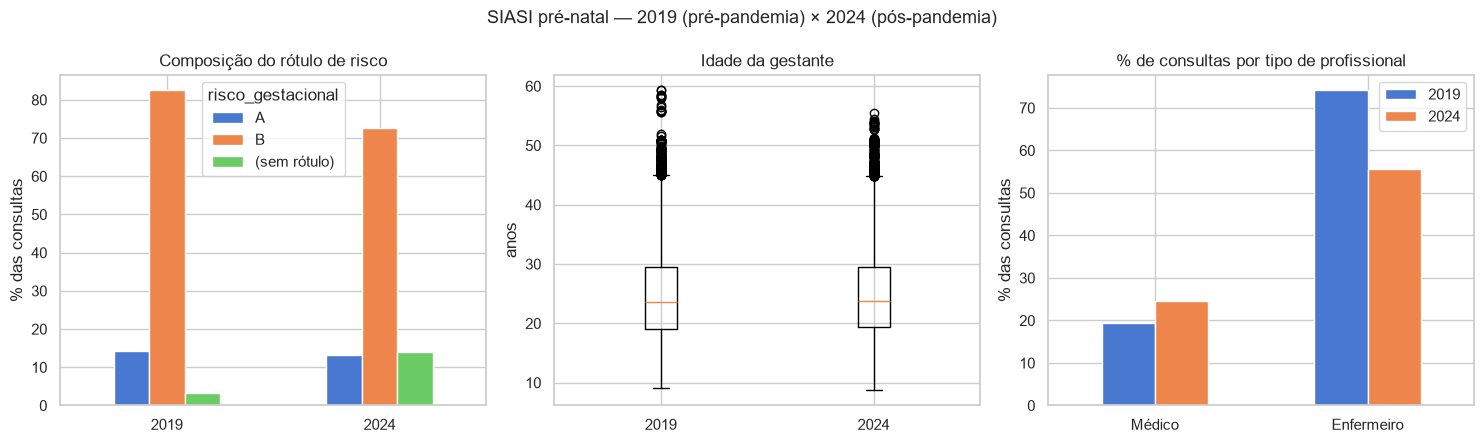

In [18]:
# Visualização comparativa 2019 × 2024
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

comp = pd.DataFrame({
    "2019": df19[TARGET_COL].value_counts(dropna=False, normalize=True) * 100,
    "2024": df[TARGET_COL].value_counts(dropna=False, normalize=True) * 100,
}).rename(index={np.nan: "(sem rótulo)"})
comp.T.plot(kind="bar", ax=axes[0], rot=0, edgecolor="white", color=sns.color_palette("muted"))
axes[0].set_title("Composição do rótulo de risco")
axes[0].set_ylabel("% das consultas")

axes[1].boxplot([df19["idade_gestante"].dropna(), df["idade_gestante"].dropna()],
                tick_labels=["2019", "2024"])
axes[1].set_title("Idade da gestante")
axes[1].set_ylabel("anos")

prof = pd.DataFrame({
    "2019": [df19["atendida_por_medico"].mean() * 100, df19["atendida_por_enfermeiro"].mean() * 100],
    "2024": [df["atendida_por_medico"].mean() * 100, df["atendida_por_enfermeiro"].mean() * 100],
}, index=["Médico", "Enfermeiro"])
prof.plot(kind="bar", ax=axes[2], rot=0, edgecolor="white", color=sns.color_palette("muted"))
axes[2].set_title("% de consultas por tipo de profissional")
axes[2].set_ylabel("% das consultas")

plt.suptitle("SIASI pré-natal — 2019 (pré-pandemia) × 2024 (pós-pandemia)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparacao_2019_2024.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Pré-processamento

In [19]:
from preprocess import build_preprocessor, get_feature_names

# Modelagem usa apenas as linhas com rótulo de risco (~86% do dataset)
df_model = df.dropna(subset=[TARGET_COL]).copy()
n_dropped = len(df) - len(df_model)
print(f"Linhas sem rótulo descartadas: {n_dropped} ({n_dropped / len(df):.1%})")

# Fora das features: o alvo, o identificador da gestação (serve só para o split)
# e as colunas de finalização (data leakage — só existem quando a gestação termina)
groups = df_model[GROUP_COL]
drop_cols = [TARGET_COL, GROUP_COL] + [c for c in LEAKAGE_COLS if c in df_model.columns]
X = df_model.drop(columns=drop_cols)
y = df_model[TARGET_COL]

print(f"Features: {X.shape[1]} colunas | Amostras: {X.shape[0]}")
print(f"Classes: {sorted(y.unique())} | Gestações únicas: {groups.nunique()}")

Linhas sem rótulo descartadas: 17895 (14.1%)
Features: 29 colunas | Amostras: 109386
Classes: ['A', 'B'] | Gestações únicas: 19783


In [20]:
from sklearn.model_selection import GroupShuffleSplit

# Split por GESTAÇÃO, não por linha: como cada gestação tem várias consultas,
# um split aleatório por linha colocaria consultas da mesma gestante em treino
# e teste ao mesmo tempo (data leakage), inflando artificialmente as métricas.
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Treino: {X_train.shape[0]} consultas ({groups.iloc[train_idx].nunique()} gestações)")
print(f"Teste : {X_test.shape[0]} consultas ({groups.iloc[test_idx].nunique()} gestações)")

Treino: 87628 consultas (15826 gestações)
Teste : 21758 consultas (3957 gestações)


In [21]:
preprocessor = build_preprocessor(X_train)
preprocessor.fit(X_train)
feature_names = get_feature_names(preprocessor, X_train)

# De onde vem o total: numéricas passam 1:1; cada categórica é expandida pelo
# OneHotEncoder em uma coluna 0/1 por categoria
num_cols_prep = preprocessor.transformers_[0][2]
cat_cols_prep = preprocessor.transformers_[1][2]
onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]

print(f"Features após pré-processamento: {len(feature_names)}\n")
print(f"── Numéricas ({len(num_cols_prep)} colunas, passam 1:1) ──")
print("  " + ", ".join(num_cols_prep))
print(f"\n── Categóricas ({len(cat_cols_prep)} colunas → uma coluna 0/1 por categoria) ──")
total_dummies = 0
for col, cats in zip(cat_cols_prep, onehot.categories_):
    total_dummies += len(cats)
    exemplo = ", ".join(map(str, cats[:5])) + (" ..." if len(cats) > 5 else "")
    print(f"  {col}: {len(cats)} categorias ({exemplo})")
print(f"\nTotal: {len(num_cols_prep)} numéricas + {total_dummies} colunas one-hot = {len(feature_names)} features")

[preprocess] Colunas categóricas removidas (alta cardinalidade): {'data_ultima_menstruacao', 'nome_municipio', 'data_nascimento', 'id_consulta', 'nome_terra_indigena', 'data_consulta', 'id_gestante', 'nome_polo_base'}
[preprocess] Numéricas : 14 colunas
[preprocess] Categóricas: 7 colunas


Features após pré-processamento: 95

── Numéricas (14 colunas, passam 1:1) ──
  codigo_dsei, codigo_polo_base, codigo_terra_indigena, codigo_municipio_ibge, codigo_profissional, codigo_familia_ocupacao, codigo_ocupacao, idade_gestante, idade_gestacional_semanas, num_consulta, semana_inicio_prenatal, trimestre_inicio_prenatal, atendida_por_medico, atendida_por_enfermeiro

── Categóricas (7 colunas → uma coluna 0/1 por categoria) ──
  nome_dsei: 34 categorias (ALAGOAS E SERGIPE, ALTAMIRA, ALTO RIO JURUÁ, ALTO RIO NEGRO, ALTO RIO PURUS ...)
  uf: 24 categorias (AC, AL, AM, AP, BA ...)
  sexo: 1 categorias (F)
  tipo_localidade: 2 categorias (ACA, ALD)
  local_atendimento: 4 categorias (AL, CI, PL, UR)
  categoria_profissional: 3 categorias (ENFERMEIROS E AFINS, MÉDICOS CLÍNICOS, MÉDICOS EM ESPECIALIDADES CIRÚRGICAS)
  ocupacao_profissional: 13 categorias (Enfermeiro, Enfermeiro da estratégia de saúde da família, Enfermeiro de centro cirúrgico, Enfermeiro do trabalho, Enfermeiro sanitarist

## 8. Treinamento dos Modelos

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from preprocess import build_preprocessor

models = {
    "LogisticRegression": Pipeline([
        ("prep", build_preprocessor(X_train)),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "DecisionTree": Pipeline([
        ("prep", build_preprocessor(X_train)),
        ("model", DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}

trained_models = {}
for name, pipeline in models.items():
    print(f"Treinando {name}...")
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    print(f"  ✓ {name} treinado.")

[preprocess] Colunas categóricas removidas (alta cardinalidade): {'data_ultima_menstruacao', 'nome_municipio', 'data_nascimento', 'id_consulta', 'nome_terra_indigena', 'data_consulta', 'id_gestante', 'nome_polo_base'}
[preprocess] Numéricas : 14 colunas
[preprocess] Categóricas: 7 colunas


[preprocess] Colunas categóricas removidas (alta cardinalidade): {'data_ultima_menstruacao', 'nome_municipio', 'data_nascimento', 'id_consulta', 'nome_terra_indigena', 'data_consulta', 'id_gestante', 'nome_polo_base'}
[preprocess] Numéricas : 14 colunas
[preprocess] Categóricas: 7 colunas
Treinando LogisticRegression...


  ✓ LogisticRegression treinado.
Treinando DecisionTree...


  ✓ DecisionTree treinado.


### 8.1 Ablação — impacto das features derivadas

Para **evidenciar a contribuição da engenharia de features** (seção 5), treinamos os mesmos dois modelos, com os mesmos hiperparâmetros e o mesmo split, em duas variantes:

1. **Baseline**: apenas as colunas originais do dataset (majoritariamente administrativas);
2. **Completa**: colunas originais + as features derivadas.

A diferença entre as duas linhas de cada modelo isola o efeito das features derivadas — qualquer ganho vem exclusivamente delas.

[preprocess] Colunas categóricas removidas (alta cardinalidade): {'data_ultima_menstruacao', 'nome_municipio', 'data_nascimento', 'id_consulta', 'nome_terra_indigena', 'data_consulta', 'id_gestante', 'nome_polo_base'}


[preprocess] Numéricas : 7 colunas
[preprocess] Categóricas: 7 colunas


[preprocess] Colunas categóricas removidas (alta cardinalidade): {'data_ultima_menstruacao', 'nome_municipio', 'data_nascimento', 'id_consulta', 'nome_terra_indigena', 'data_consulta', 'id_gestante', 'nome_polo_base'}
[preprocess] Numéricas : 7 colunas
[preprocess] Categóricas: 7 colunas


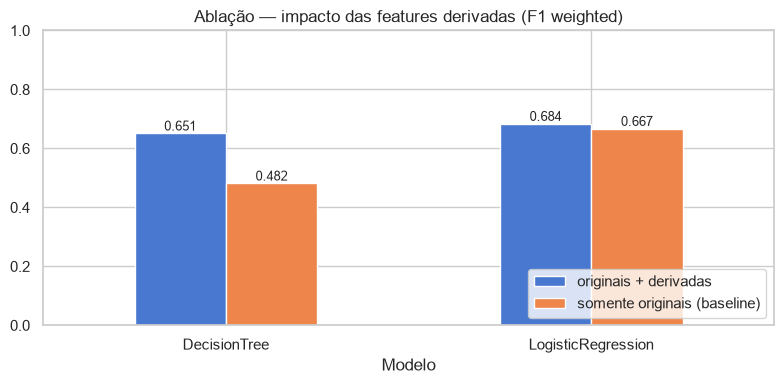

Accuracy  Recall classe A  \
Modelo             Features                                                  
LogisticRegression somente originais (baseline)    0.6156           0.6046   
                   originais + derivadas           0.6358           0.6171   
DecisionTree       somente originais (baseline)    0.4315           0.8388   
                   originais + derivadas           0.5980           0.7908   

                                                 F1 (weighted)  
Modelo             Features                                     
LogisticRegression somente originais (baseline)         0.6673  
                   originais + derivadas                0.6843  
DecisionTree       somente originais (baseline)         0.4819  
                   originais + derivadas                0.6515

In [23]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

def _scores(pipe, Xte):
    y_pred = pipe.predict(Xte)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall classe A": recall_score(y_test, y_pred, pos_label="A"),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted"),
    }

# Baseline: mesmos modelos e hiperparâmetros, SEM as 5 features derivadas
baseline_cols = [c for c in X_train.columns if c not in new_feats]

rows = []
for name, model_factory in {
    "LogisticRegression": lambda: LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
    "DecisionTree": lambda: DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
}.items():
    pipe_base = Pipeline([
        ("prep", build_preprocessor(X_train[baseline_cols])),
        ("model", model_factory()),
    ])
    pipe_base.fit(X_train[baseline_cols], y_train)
    rows.append({"Modelo": name, "Features": "somente originais (baseline)",
                 **_scores(pipe_base, X_test[baseline_cols])})
    rows.append({"Modelo": name, "Features": "originais + derivadas",
                 **_scores(trained_models[name], X_test)})

df_ablation = pd.DataFrame(rows).set_index(["Modelo", "Features"]).round(4)
df_ablation.to_csv(METRICS_DIR / "ablation_features_derivadas.csv")

ax = df_ablation["F1 (weighted)"].unstack("Features").plot(
    kind="bar", figsize=(8, 4), rot=0, edgecolor="white", color=sns.color_palette("muted")
)
ax.set_title("Ablação — impacto das features derivadas (F1 weighted)")
ax.set_ylim(0, 1.0)
ax.legend(title="", loc="lower right")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ablation_f1.png", dpi=150)
plt.show()

df_ablation

## 9. Avaliação dos Modelos

In [24]:
from evaluate import evaluate_model, compare_models

all_metrics = []
for name, pipeline in trained_models.items():
    metrics = evaluate_model(name, pipeline, X_test, y_test, save=True)
    all_metrics.append(metrics)


Modelo : LogisticRegression
              precision    recall  f1-score   support

           A      0.243     0.617     0.349      3437
           B      0.899     0.639     0.747     18321

    accuracy                          0.636     21758
   macro avg      0.571     0.628     0.548     21758
weighted avg      0.795     0.636     0.684     21758

Accuracy : 0.6358
Recall   : 0.6358
F1-score : 0.6843
Métricas salvas em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\metrics\LogisticRegression_metrics.json


Matriz de confusão salva em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\LogisticRegression_confusion_matrix.png



Modelo : DecisionTree
              precision    recall  f1-score   support

           A      0.253     0.791     0.383      3437
           B      0.935     0.562     0.702     18321

    accuracy                          0.598     21758
   macro avg      0.594     0.676     0.543     21758
weighted avg      0.827     0.598     0.651     21758

Accuracy : 0.598
Recall   : 0.598
F1-score : 0.6515
Métricas salvas em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\metrics\DecisionTree_metrics.json


Matriz de confusão salva em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\DecisionTree_confusion_matrix.png


In [25]:
df_comparison = compare_models(all_metrics)
df_comparison


=== Comparação de Modelos ===
                    Accuracy  Recall (weighted)  F1 (weighted)
Modelo                                                        
LogisticRegression    0.6358             0.6358         0.6843
DecisionTree          0.5980             0.5980         0.6515

Comparação salva em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\metrics\models_comparison.csv


,Accuracy,Recall (weighted),F1 (weighted)
Modelo,,,
LogisticRegression,0.6358,0.6358,0.6843
DecisionTree,0.5980,0.5980,0.6515


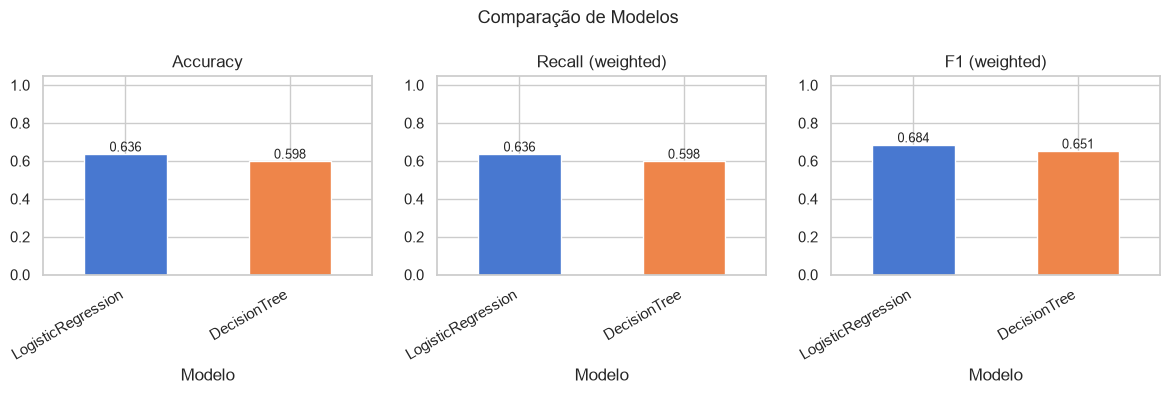

In [26]:
# Visualização comparativa
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics_to_plot = ["Accuracy", "Recall (weighted)", "F1 (weighted)"]
for ax, metric in zip(axes, metrics_to_plot):
    df_comparison[metric].plot(kind="bar", ax=ax, color=sns.color_palette("muted"), edgecolor="white")
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(df_comparison.index, rotation=30, ha="right")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.suptitle("Comparação de Modelos", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "models_comparison.png", dpi=150)
plt.show()

## 10. Explicabilidade

### 10.1 Feature Importance (Árvore de Decisão)

In [27]:
from explain import plot_feature_importance

for name, pipeline in trained_models.items():
    # Obtém feature names após pré-processamento
    prep = pipeline.named_steps["prep"]
    prep.fit(X_train)  # garante que está ajustado
    fn = get_feature_names(prep, X_train)
    plot_feature_importance(name, pipeline, feature_names=fn)

[explain] LogisticRegression não possui feature_importances_. Pulando.


Feature importance salva em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\DecisionTree_feature_importance.png


### 10.2 SHAP — Explicabilidade Global e Local

In [28]:
from explain import plot_shap

for name, pipeline in trained_models.items():
    prep = pipeline.named_steps["prep"]
    fn = get_feature_names(prep, X_train)
    plot_shap(name, pipeline, X_test, feature_names=fn, max_samples=200)

  0%|          | 0/50 [00:00<?, ?it/s]

SHAP summary salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\LogisticRegression_shap_summary.png


SHAP local (waterfall) salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\LogisticRegression_shap_local.png


SHAP summary salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\DecisionTree_shap_summary.png


SHAP local (waterfall) salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\DecisionTree_shap_local.png


## 11. Conclusão Crítica

### Resumo dos resultados

| Modelo | Accuracy | Recall classe A | Precision classe A | F1 (weighted) |
|---|---|---|---|---|
| Regressão Logística | 0,636 | 0,617 | 0,243 | 0,684 |
| Árvore de Decisão | 0,598 | **0,791** | 0,253 | 0,652 |

Com o conjunto de teste de 21.758 consultas (3.957 gestações nunca vistas no treino):

- A **Árvore de Decisão** identifica **79% das gestações de alto risco** — para um sistema de triagem, é o modelo preferível, pois o erro grave neste domínio é o falso negativo (gestante de alto risco classificada como baixo risco e privada de acompanhamento reforçado).
- A **Regressão Logística** é mais equilibrada entre as classes (F1 maior), mas deixa escapar ~38% dos casos de alto risco.
- A **precision da classe A (~0,25)** significa que ~3 em cada 4 alertas são falsos positivos. Num fluxo de triagem isso é aceitável — o custo de uma reavaliação é muito menor que o de um caso perdido — mas inviabiliza o uso como decisor automático.

### As informações que mais pesaram na classificação

Ranking de importância da Árvore de Decisão (confirmado pelo SHAP):

| Posição | Feature | Importância | Natureza |
|---|---|---|---|
| 1º | `idade_gestante` | **~52%** | Demográfica (derivada) |
| 2º | `codigo_terra_indigena` | ~17% | Territorial |
| 3º | `codigo_municipio_ibge` | ~9% | Territorial |
| 4º | `nome_dsei_LESTE DE RORAIMA` | ~8% | Territorial |
| 5º | `codigo_dsei` | ~6% | Territorial |
| 6º | `codigo_polo_base` | ~4% | Territorial |

Em síntese: **~52% idade + ~44% território**. O modelo aprendeu essencialmente *"quem é ela (idade) e onde ela vive"*. Features de acompanhamento (`num_consulta`, `semana_inicio_prenatal`, `idade_gestacional_semanas`) e de profissional tiveram importância ~zero — coerente com a análise de correlação e os boxplots da seção 6.

### O que um dataset administrativo permite (e não permite) concluir

O SIASI não contém variáveis clínicas (pressão arterial, glicemia, exames, histórico obstétrico) — que são exatamente o que preenche a lacuna diagnóstica (ver o notebook `02_maternal_risk`, onde dados clínicos elevam a precision de alto risco para ~0,89). Diante disso, as conclusões legítimas desta análise são:

1. **Existe sinal real em dados puramente demográfico-territoriais**: idade e território sozinhos capturam 79% dos casos de alto risco. Isso viabiliza uma triagem populacional de baixo custo, que não exige nenhum exame — útil justamente no contexto de escassez assistencial.
2. **O peso da idade é clinicamente coerente**: extremos de idade materna são fator de risco consagrado na literatura, e o dataset tem 17% de consultas de menores de 18 anos.
3. **O peso do território tem dupla leitura** — e distinguir entre elas exigiria dados externos: (a) diferenças **epidemiológicas reais** entre regiões (acesso, condições endêmicas, infraestrutura); ou (b) diferenças de **prática de classificação** entre equipes/DSEIs (o rótulo é atribuído por humanos, e cada distrito pode aplicar critérios mais ou menos rigorosos). Se (b) domina, o modelo aprende hábitos de registro, não risco biológico.
4. **O teto de desempenho é imposto pelos dados, não pelo algoritmo**: a precision de ~0,25 na classe A indica que consultas "parecidas" (mesma idade, mesma região) recebem rótulos diferentes — a informação que as distingue é clínica e não está no dataset. Trocar de algoritmo não resolve; enriquecer as features sim.
5. **O valor maior do SIASI está na dimensão assistencial**: cobertura, precocidade e intensidade do pré-natal, quem atende, disparidades regionais e evolução temporal (seção 6.1: mais consultas por gestação e início mais precoce em 2024, mas desfechos adversos piores que em 2019).

### Escolha da métrica

**Accuracy é enganosa neste problema**: com 84% das consultas rotuladas como baixo risco, um modelo que sempre previsse "B" teria accuracy de 0,84 e recall zero na classe A — inútil. Por isso priorizamos **recall da classe A** (critério clínico) e **F1 weighted** (equilíbrio geral), reportando accuracy apenas como referência.

### O que a ablação demonstrou (seção 8.1)

As features derivadas das datas elevaram o F1 da árvore de **0,48 para 0,65** e a accuracy de 0,43 para 0,60, mantendo recall alto na classe A. O modelo passou a decidir por um fator clinicamente reconhecido (idade materna) em vez de apenas códigos administrativos. Os indicadores de profissional (`atendida_por_medico`/`atendida_por_enfermeiro`) não alteraram as métricas — a informação já era capturada pelo one-hot de `categoria_profissional` — mas revelaram na EDA que ~70% das consultas de alto risco ocorrem sem médico.

### Decisões metodológicas que sustentam a validade dos resultados

1. **Split por gestação** (`GroupShuffleSplit`): cada linha é uma consulta e a mesma gestação tem ~6,4 consultas; um split aleatório por linha colocaria a mesma gestante em treino e teste, inflando as métricas (data leakage).
2. **Exclusão de `data_finalizacao` e `motivo_finalizacao`** como features: só são conhecidas ao fim da gestação — usá-las seria "colar a resposta".
3. **`num_consulta` cumulativa**: o total de consultas da gestação também só é conhecido no fim; usamos apenas a ordem da consulta atual.
4. **Descarte dos 14% sem rótulo — decisão justificada, não viés**: a investigação mostrou que o padrão é estrutural, não aleatório. **100%** das consultas de cirurgiões-dentistas, nutricionistas, técnicos de enfermagem e psicólogos não têm rótulo de risco, contra **0%** das consultas de médicos e enfermeiros. Ou seja: a classificação de risco gestacional só faz parte das consultas médicas/de enfermagem — os registros descartados são de tipos de atendimento que não avaliam risco, e não gestantes excluídas da análise.

### Limitações e uso responsável

1. **Suporte à decisão, não diagnóstico**: o modelo prioriza a fila de atenção; **o profissional de saúde sempre tem a palavra final**.
2. **Dados administrativos**: registros do SIASI podem conter erros de digitação, datas inconsistentes (tratadas na seção 5) e subnotificação.
3. **Viés de cobertura**: gestantes fora do sistema de saúde indígena não estão representadas; o modelo não generaliza para outras populações.
4. **Rótulo imperfeito**: o "risco gestacional" registrado é a avaliação do profissional na consulta — o modelo aprende a reproduzir esse julgamento, incluindo seus eventuais vieses (ver a dupla leitura do peso territorial acima), e não o desfecho clínico real.

### O modelo pode ser usado na prática? Como?

Sim, como **ferramenta de triagem e priorização**: ordenar a fila de acompanhamento dos DSEIs, sinalizando gestantes com perfil de alto risco para avaliação prioritária — especialmente onde há escassez de profissionais. O recall de 0,79 com cobertura de 4 em cada 5 casos de alto risco agrega valor real, desde que: (i) os alertas sejam sempre validados por um profissional; (ii) o desempenho seja monitorado ao longo do tempo; (iii) a precision seja comunicada com transparência às equipes (a maioria dos alertas será descartada após avaliação — comportamento esperado de uma triagem sensível).

### Próximos passos

- **Enriquecer com variáveis clínicas** (o caminho com maior potencial, como demonstra o notebook `02_maternal_risk`): integração com outros sistemas de saúde ou registro de sinais vitais no SIASI.
- Terceiro modelo (RandomForest/KNN) e tuning com `GridSearchCV` + validação cruzada por grupos (`GroupKFold`).
- Balanceamento com SMOTE (imbalanced-learn) para tentar elevar a precision da classe A.
- Agregação por gestação (prever o risco da **gestante**, não da consulta) e análise dos desfechos (`motivo_finalizacao`) como validação externa do rótulo.
- Testar o modelo treinado em 2024 sobre os dados de 2019 (validação temporal).
- Validação com especialistas em saúde materno-fetal e saúde indígena.